In [1]:
"""
Exercise 2.2 - Supervised Learning of the Markov Control a*(t, x)

We train an FFN network (2 hidden layers of size 100) to approximate the
optimal Markov control
    a*(t, x) = -D^{-1} M' S(t) x
obtained analytically in Exercise 1.1.

The FFN architecture is taken directly from:
    M. Sabate-Vidales, Deep-PDE-Solvers, lib/networks.py  (reference [1])

The input to the network is (t, x) concatenated to R^3.
The output is 2-dimensional (one component per control dimension).
Sizes list: [3, 100, 100, 2]  (input -> hidden1 -> hidden2 -> output).

Training : Adam optimiser minimising MSE on randomly sampled (t, x) pairs
           drawn from [0, T] x [-3, 3]^2.
Output   : Training loss curve saved to exercise_2_2_loss.png.
"""

import numpy as np
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

In [2]:
# -----------------------------------------------------------------------
# LQRSolver  (copied from Ex 1.1 so this file runs standalone)
# -----------------------------------------------------------------------

class LQRSolver:
    """
    Solves the LQR problem via the Riccati ODE.

    Minimise J(t,x) = E[ int_t^T (X'CX + a'Da) ds + X_T' R X_T ]
    subject to  dX = (HX + Ma) dt + sigma dW,  X_t = x.

    Value function:
        v(t, x) = x' S(t) x + int_t^T tr(sigma sigma' S(r)) dr
    Optimal control:
        a*(t, x) = -D^{-1} M' S(t) x
    """

    def __init__(self, H, M, C, D, R, sigma, T):
        self.H     = np.array(H,     dtype=float)
        self.M     = np.array(M,     dtype=float)
        self.C     = np.array(C,     dtype=float)
        self.D     = np.array(D,     dtype=float)
        self.R     = np.array(R,     dtype=float)
        self.sigma = np.array(sigma, dtype=float)
        self.T     = float(T)
        self.d     = self.H.shape[0]

        self.D_inv    = np.linalg.inv(self.D)
        self.MD_invMT = self.M @ self.D_inv @ self.M.T

        self.S_interp        = None
        self.integral_interp = None

    def _riccati_rhs(self, tau, S_flat):
        """
        RHS of the Riccati ODE in forward time tau = T - t.

        Original:  S'(t) = -2H'S + S M D^{-1} M' S - C,  S(T) = R.
        Flipped:   dS/dtau = 2H'S - S M D^{-1} M' S + C,  S(0) = R.
        """
        S  = S_flat.reshape(self.d, self.d)
        dS = 2.0 * self.H.T @ S - S @ self.MD_invMT @ S + self.C
        return dS.reshape(-1)

    def solve_riccati(self, time_grid):
        """
        Solve the Riccati ODE on the given time grid and build interpolators
        for S(t) and the integral correction term.

        Args:
            time_grid : array-like of times in [0, T] (numpy or torch)

        Returns:
            S_values : ndarray of shape (len(time_grid), d, d)
        """
        if isinstance(time_grid, torch.Tensor):
            time_grid = time_grid.detach().cpu().numpy()
        time_grid = np.array(time_grid, dtype=float).reshape(-1)

        tau_grid = self.T - time_grid
        sol = solve_ivp(
            self._riccati_rhs,
            (0.0, self.T),
            self.R.reshape(-1),
            t_eval=tau_grid[::-1],
            method='RK45',
            rtol=1e-8,
            atol=1e-10,
        )
        if not sol.success:
            raise RuntimeError(f"Riccati solve failed: {sol.message}")

        S_values = sol.y[:, ::-1].T.reshape(-1, self.d, self.d)
        S_values = 0.5 * (S_values + np.transpose(S_values, (0, 2, 1)))

        kind = 'cubic' if len(time_grid) >= 4 else 'linear'
        self.S_interp = [
            [
                interp1d(time_grid, S_values[:, i, j], kind=kind,
                         bounds_error=False, fill_value='extrapolate')
                for j in range(self.d)
            ]
            for i in range(self.d)
        ]

        ss         = self.sigma @ self.sigma.T
        trace_vals = np.array([np.trace(ss @ S) for S in S_values], dtype=float)
        integral   = np.zeros(len(time_grid), dtype=float)
        for i in range(len(time_grid) - 2, -1, -1):
            dt          = time_grid[i + 1] - time_grid[i]
            integral[i] = integral[i + 1] + 0.5 * dt * (trace_vals[i] + trace_vals[i + 1])

        self.integral_interp = interp1d(
            time_grid, integral, kind='linear',
            bounds_error=False, fill_value='extrapolate',
        )
        return S_values

    def _get_S(self, t):
        """Evaluate S(t) for a vector of times. Accepts numpy or torch."""
        if self.S_interp is None:
            raise RuntimeError("Call solve_riccati first.")
        is_torch = isinstance(t, torch.Tensor)
        t_np     = t.detach().cpu().numpy() if is_torch else np.asarray(t, dtype=float)
        t_flat   = t_np.reshape(-1)
        S_out    = np.zeros((len(t_flat), self.d, self.d), dtype=float)
        for i in range(self.d):
            for j in range(self.d):
                S_out[:, i, j] = self.S_interp[i][j](t_flat)
        if is_torch:
            return torch.from_numpy(S_out).float().to(t.device)
        return S_out

    def value_function(self, t_batch, x_batch):
        """
        Compute v(t, x) = x' S(t) x + int_t^T tr(sigma sigma' S(r)) dr.

        Args:
            t_batch : torch tensor, shape (batch_size,)
            x_batch : torch tensor, shape (batch_size, 1, d)

        Returns:
            v : torch tensor, shape (batch_size, 1)
        """
        S   = self._get_S(t_batch)
        x   = x_batch.squeeze(1)
        xSx = torch.sum((x.unsqueeze(1) @ S).squeeze(1) * x, dim=1)
        integral = torch.from_numpy(
            self.integral_interp(t_batch.detach().cpu().numpy())
        ).float().to(t_batch.device)
        return (xSx + integral).unsqueeze(1)

    def optimal_control(self, t_batch, x_batch):
        """
        Compute a*(t, x) = -D^{-1} M' S(t) x.

        Args:
            t_batch : torch tensor, shape (batch_size,)
            x_batch : torch tensor, shape (batch_size, 1, d)

        Returns:
            a : torch tensor, shape (batch_size, d)
        """
        S          = self._get_S(t_batch)
        x          = x_batch.squeeze(1)
        neg_DinvMT = torch.from_numpy(-self.D_inv @ self.M.T).float().to(t_batch.device)
        Sx         = (S @ x.unsqueeze(2)).squeeze(2)
        return (neg_DinvMT @ Sx.unsqueeze(2)).squeeze(2)

In [3]:
# -----------------------------------------------------------------------
# FFN  (Feed-Forward Network)
# Taken directly from reference [1]:  lib/networks.py  (Sabate-Vidales 2021)
# https://github.com/msabvid/Deep-PDE-Solvers
# -----------------------------------------------------------------------

class FFN(nn.Module):
    """
    Fully-connected feed-forward network with flexible depth and width.

    The architecture is determined entirely by the `sizes` list:
        sizes = [d_in, h_1, h_2, ..., d_out]

    Between every consecutive pair of layers a Linear transform is applied.
    After each hidden layer `activation` is applied.
    After the final layer `output_activation` is applied (default: Identity,
    i.e. no activation — appropriate for regression targets).

    Optionally, BatchNorm1d is inserted after every Linear layer when
    batch_norm=True; this is left off here (default) since our batches are
    i.i.d. uniform samples and BatchNorm would add unnecessary complexity.

    For Exercise 2.2:
        sizes = [3, 100, 100, 2]
        input  = concat(t, x) in R^{1+2} = R^3
        output = a*(t, x) in R^2

    Args:
        sizes             : list of layer widths, e.g. [3, 100, 100, 2]
        activation        : hidden activation class (default nn.Tanh)
        output_activation : output activation class (default nn.Identity)
        batch_norm        : whether to insert BatchNorm1d layers (default False)
    """

    def __init__(self, sizes, activation=nn.Tanh, output_activation=nn.Identity,
                 batch_norm=False):
        super().__init__()

        layers = [nn.BatchNorm1d(sizes[0])] if batch_norm else []
        for j in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[j], sizes[j + 1]))
            if batch_norm:
                layers.append(nn.BatchNorm1d(sizes[j + 1], affine=True))
            if j < len(sizes) - 2:
                layers.append(activation())       # hidden activation
            else:
                layers.append(output_activation()) # output activation

        self.net = nn.Sequential(*layers)

    def freeze(self):
        for p in self.parameters():
            p.requires_grad = False

    def unfreeze(self):
        for p in self.parameters():
            p.requires_grad = True

    def forward(self, x):
        """
        Args:
            x : torch tensor, shape (batch, sizes[0])

        Returns:
            out : torch tensor, shape (batch, sizes[-1])
        """
        return self.net(x)

In [4]:
# -----------------------------------------------------------------------
# Problem setup  (same matrices as Exercise 1.1 / 1.2 / 2.1)
# -----------------------------------------------------------------------

H     = np.array([[0.5, 0.1], [0.1, 0.3]])
M     = np.array([[1.0, 0.5], [0.0, 1.0]])
C     = np.array([[2.0, 0.5], [0.5, 1.0]])
D     = np.array([[2.0, 0.0], [0.0, 1.0]])
R_mat = np.array([[1.0, 0.0], [0.0, 2.0]])
sigma = np.array([[0.3, 0.1], [0.0, 0.2]])
T     = 1.0
d     = 2   # spatial dimension

# Solve Riccati ODE once on a fine grid
solver = LQRSolver(H, M, C, D, R_mat, sigma, T)
solver.solve_riccati(np.linspace(0.0, T, 2000))
print("Riccati ODE solved on fine grid with 2000 points.")

Riccati ODE solved on fine grid with 2000 points.


In [9]:
# -----------------------------------------------------------------------
# Training
# -----------------------------------------------------------------------

torch.manual_seed(42)

# hyper-parameters
# sizes: input (t,x) in R^3 -> hidden 100 -> hidden 100 -> output a in R^2
SIZES     = [1 + d, 100, 100, d]   # [3, 100, 100, 2]
N_DATA    = 10_000
N_ITER    = 3_000
LR        = 1e-3
LOG_EVERY = 100

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# FFN takes a single concatenated input vector, so forward(tx) where tx = cat(t, x)
net = FFN(sizes=SIZES, activation=nn.Tanh, output_activation=nn.Identity).to(device)
optimiser = torch.optim.Adam(net.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimiser, milestones=[1000, 2000], gamma=0.1
)

n_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"Network architecture  : {SIZES}")
print(f"Trainable parameters  : {n_params:,}")


def sample_batch(n, t_low=0.0, t_high=T, x_low=-3.0, x_high=3.0):
    """
    Sample n i.i.d. points uniformly from [t_low, t_high] x [x_low, x_high]^d
    and compute the analytical optimal control as the supervised target.

    Returns:
        tx       : (n, 1+d)  float32  -- concat(t, x), ready for FFN.forward
        a_target : (n, d)    float32  -- target control a*(t, x)
    """
    t_np = np.random.uniform(t_low, t_high, size=(n, 1)).astype(np.float32)
    x_np = np.random.uniform(x_low, x_high, size=(n, d)).astype(np.float32)

    # optimal_control expects t of shape (n,) and x of shape (n, 1, d)
    t_1d  = torch.from_numpy(t_np.squeeze(1))
    x_lqr = torch.from_numpy(x_np).unsqueeze(1)          # (n, 1, d)

    with torch.no_grad():
        a_target = solver.optimal_control(t_1d, x_lqr)   # (n, d)

    # FFN takes a single concatenated vector (t, x) in R^{1+d}
    tx = torch.from_numpy(np.concatenate([t_np, x_np], axis=1)).to(device)  # (n, 1+d)
    return tx, a_target.to(device)


loss_history    = []
loss_a1_history = []
loss_a2_history = []

for it in range(1, N_ITER + 1):
    tx_b, a_target = sample_batch(N_DATA)

    optimiser.zero_grad()
    a_pred = net(tx_b)                                   # (n, d)
    loss   = torch.mean((a_pred - a_target) ** 2)
    loss.backward()
    optimiser.step()

    loss_history.append(loss.item())
    loss_a1_history.append(torch.mean((a_pred[:, 0] - a_target[:, 0]) ** 2).item())
    loss_a2_history.append(torch.mean((a_pred[:, 1] - a_target[:, 1]) ** 2).item())

    if it % LOG_EVERY == 0 or it == 1:
        print(f"Iteration {it:5d}/{N_ITER}  |  MSE loss = {loss.item():.4e}")

print("\nTraining complete.")

Using device: cpu
Network architecture  : [3, 100, 100, 2]
Trainable parameters  : 10,702
Iteration     1/3000  |  MSE loss = 6.3802e+00
Iteration   100/3000  |  MSE loss = 2.2033e-01
Iteration   200/3000  |  MSE loss = 1.0715e-01
Iteration   300/3000  |  MSE loss = 4.5746e-02
Iteration   400/3000  |  MSE loss = 1.9205e-02
Iteration   500/3000  |  MSE loss = 1.2964e-02
Iteration   600/3000  |  MSE loss = 1.0536e-02
Iteration   700/3000  |  MSE loss = 8.2492e-03
Iteration   800/3000  |  MSE loss = 6.4935e-03
Iteration   900/3000  |  MSE loss = 4.9223e-03
Iteration  1000/3000  |  MSE loss = 3.6629e-03
Iteration  1100/3000  |  MSE loss = 2.9250e-03
Iteration  1200/3000  |  MSE loss = 2.4131e-03
Iteration  1300/3000  |  MSE loss = 1.9612e-03
Iteration  1400/3000  |  MSE loss = 1.6329e-03
Iteration  1500/3000  |  MSE loss = 1.2442e-03
Iteration  1600/3000  |  MSE loss = 1.0297e-03
Iteration  1700/3000  |  MSE loss = 8.9318e-04
Iteration  1800/3000  |  MSE loss = 7.3939e-04
Iteration  1900/3

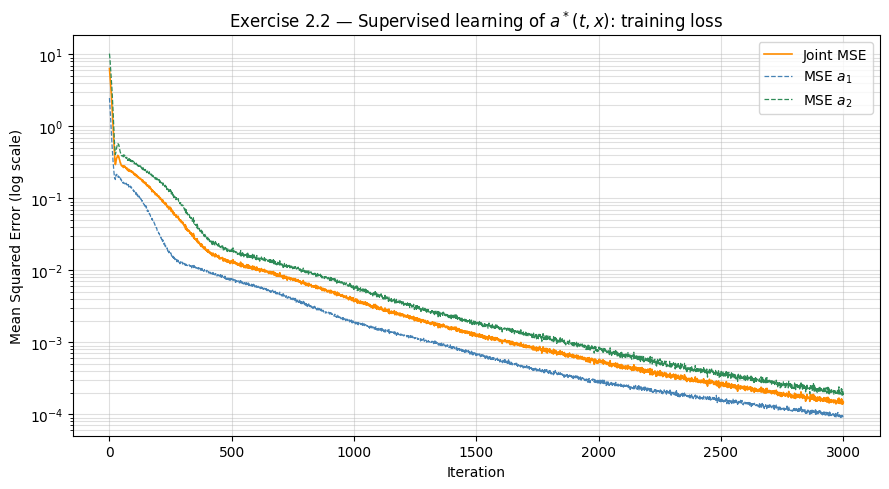

Saved exercise_2_2_loss.png


In [10]:
# -----------------------------------------------------------------------
# Plot 1: training loss curve (joint + per-component)
# -----------------------------------------------------------------------

iters = np.arange(1, N_ITER + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(iters, loss_history,    linewidth=1.2, color='darkorange', label='Joint MSE')
ax.semilogy(iters, loss_a1_history, linewidth=0.9, color='steelblue',  linestyle='--', label='MSE $a_1$')
ax.semilogy(iters, loss_a2_history, linewidth=0.9, color='seagreen',   linestyle='--', label='MSE $a_2$')
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean Squared Error (log scale)')
ax.set_title('Exercise 2.2 — Supervised learning of $a^*(t, x)$: training loss')
ax.legend()
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.savefig('exercise_2_2_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved exercise_2_2_loss.png')

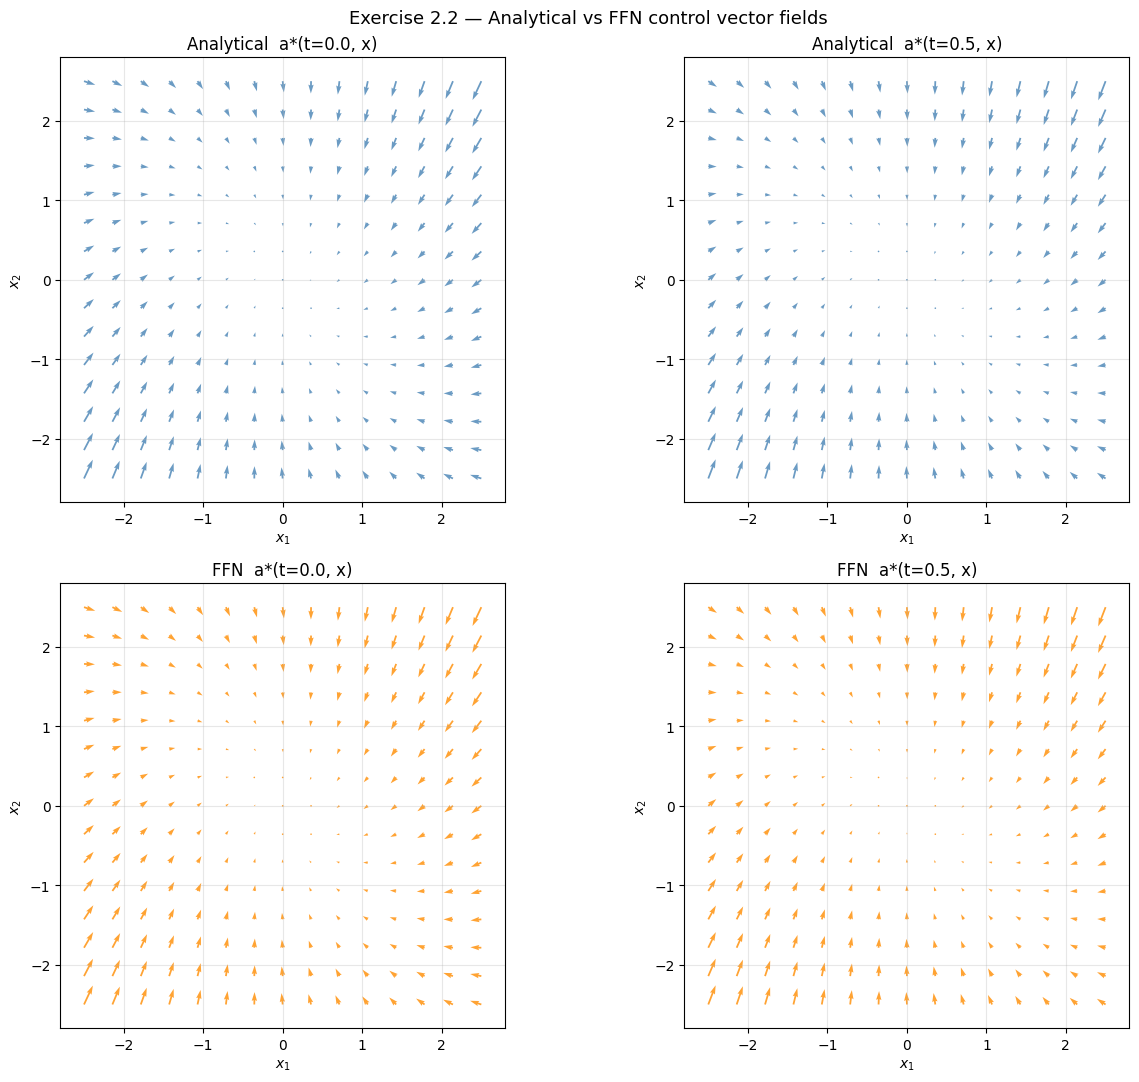

Saved exercise_2_2_vector_fields.png


In [11]:
# -----------------------------------------------------------------------
# Plot 2: analytical vs FFN control vector fields at t = 0 and t = 0.5
# Each arrow shows the 2D control a*(t, x) at a grid of spatial points.
# -----------------------------------------------------------------------

net.eval()

x_range = np.linspace(-2.5, 2.5, 15)
X1, X2  = np.meshgrid(x_range, x_range)
x_np    = np.stack([X1.ravel(), X2.ravel()], axis=1).astype(np.float32)  # (225, 2)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

for col, t_val in enumerate([0.0, 0.5]):
    n_pts = x_np.shape[0]
    t_np_col = np.full((n_pts, 1), t_val, dtype=np.float32)

    # analytical target
    t_1d  = torch.from_numpy(t_np_col.squeeze(1))
    x_lqr = torch.from_numpy(x_np).unsqueeze(1)           # (n, 1, d)
    with torch.no_grad():
        a_true = solver.optimal_control(t_1d, x_lqr).numpy()  # (n, 2)

    # FFN prediction
    tx = torch.from_numpy(np.concatenate([t_np_col, x_np], axis=1)).to(device)
    with torch.no_grad():
        a_nn = net(tx).cpu().numpy()                           # (n, 2)

    for row, (a_vals, label, color) in enumerate([
        (a_true, 'Analytical', 'steelblue'),
        (a_nn,   'FFN',        'darkorange'),
    ]):
        ax = axes[row, col]
        ax.quiver(
            X1.ravel(), X2.ravel(),
            a_vals[:, 0], a_vals[:, 1],
            color=color, alpha=0.8,
            scale=30, scale_units='inches'
        )
        ax.set_xlabel('$x_1$')
        ax.set_ylabel('$x_2$')
        ax.set_title(f'{label}  a*(t={t_val}, x)')
        ax.set_xlim(-2.8, 2.8)
        ax.set_ylim(-2.8, 2.8)
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')

plt.suptitle('Exercise 2.2 — Analytical vs FFN control vector fields', fontsize=13)
plt.tight_layout()
plt.savefig('exercise_2_2_vector_fields.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved exercise_2_2_vector_fields.png')

In [12]:
# -----------------------------------------------------------------------
# Quantitative evaluation on a held-out test set
# -----------------------------------------------------------------------

N_TEST = 50_000
net.eval()

tx_test, a_true_test = sample_batch(N_TEST)

with torch.no_grad():
    a_pred_test = net(tx_test)   # (N_TEST, d)

# MSE over both output components jointly
mse_test  = torch.mean((a_pred_test - a_true_test) ** 2).item()
rmse_test = mse_test ** 0.5

# per-component MSE
mse_comp = torch.mean((a_pred_test - a_true_test) ** 2, dim=0)

# relative L2 error
rel_err = (
    torch.mean((a_pred_test - a_true_test) ** 2) ** 0.5
    / torch.mean(a_true_test ** 2) ** 0.5
).item()

print(f"Test set size         : {N_TEST:,}")
print(f"Test MSE  (joint)     : {mse_test:.4e}")
print(f"Test RMSE (joint)     : {rmse_test:.4e}")
print(f"Test MSE  (a_1)       : {mse_comp[0].item():.4e}")
print(f"Test MSE  (a_2)       : {mse_comp[1].item():.4e}")
print(f"Relative L2 error     : {rel_err * 100:.3f} %")

Test set size         : 50,000
Test MSE  (joint)     : 1.4865e-04
Test RMSE (joint)     : 1.2192e-02
Test MSE  (a_1)       : 9.8098e-05
Test MSE  (a_2)       : 1.9921e-04
Relative L2 error     : 0.502 %
